In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import spikeinterface
import spikeinterface.full as si
import spikeinterface.extractors as se
import spikeinterface.sorters as ss
import spikeinterface.comparison as sc
import spikeinterface.widgets as sw
import spikeinterface.postprocessing as sp
import spikeinterface.preprocessing as spre
import spikeinterface.qualitymetrics as qm
#import helper_functions as helper

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from IPython.display import display
from matplotlib.widgets import RectangleSelector
from scipy import signal

In [15]:
data_path = '/mnt/benshalom-nas/raw_data/rbs_maxtwo_desktop/harddisk24tbvol1/KCNT1_MEASlices_06062025_CA_PS/250606/M07896/Network/000003/data.raw.h5'
well_id = 'well004'

# Spike-band preprocessing for the existing downstream workflow.
low_pass = 300  # Hz
high_pass = 3000  # Hz

# LFP preprocessing for band-power analysis. Keep this separate from spike-band filtering.
lfp_low_pass = 0.5  # Hz
lfp_high_pass = 300  # Hz
apply_lfp_common_reference = True
lfp_ignore_low_freq_error = True
lfp_filter_margin_ms = 5000  # Large margin recommended by SpikeInterface for sub-1 Hz filtering

In [16]:
recording_raw = se.read_maxwell(data_path, stream_id=well_id)
recording = recording_raw  # Backward-compatible alias for notebook cells that expect `recording`.

sampling_frequency = recording_raw.get_sampling_frequency()
num_channels = recording_raw.get_num_channels()
num_samples = recording_raw.get_num_samples()
total_duration_sec = num_samples / sampling_frequency
print(f"Sampling Frequency: {sampling_frequency} Hz")
print(f"Number of Channels: {num_channels}")
print(f"Total Duration: {total_duration_sec:.2f} seconds")

The h5 compression library for Maxwell is already located in /home/yuxin/hdf5_plugin_path_maxwell/libcompression.so!
Sampling Frequency: 10000.0 Hz
Number of Channels: 899
Total Duration: 1200.04 seconds


In [17]:
recording_signed = spre.unsigned_to_signed(recording_raw)

# Existing spike-band path. Use `recording_spike` or the compatibility alias `recording` below.
recording_filt = spre.bandpass_filter(recording_signed, freq_min=low_pass, freq_max=high_pass)

# LFP path for FFT/Welch/band-power analysis. Do not reuse the 300-3000 Hz spike filter.
# SpikeInterface warns on sub-100 Hz high-pass filters because long margins are required.
recording_lfp = spre.bandpass_filter(
    recording_signed,
    freq_min=lfp_low_pass,
    freq_max=lfp_high_pass,
    margin_ms=lfp_filter_margin_ms,
    ignore_low_freq_error=lfp_ignore_low_freq_error,
)
if apply_lfp_common_reference:
    recording_lfp = spre.common_reference(recording_lfp, reference='global', operator='median')

print(f"Prepared spike-band recording: {low_pass}-{high_pass} Hz")
print(f"Prepared LFP recording: {lfp_low_pass}-{lfp_high_pass} Hz")
print(f"LFP filter margin: {lfp_filter_margin_ms} ms | ignore_low_freq_error={lfp_ignore_low_freq_error}")

Prepared spike-band recording: 300-3000 Hz
Prepared LFP recording: 0.5-300 Hz
LFP filter margin: 5000 ms | ignore_low_freq_error=True


/mnt/Vol20tb1/yuxin/app/miniconda/envs/mandar_mea/lib/python3.14/site-packages/spikeinterface/preprocessing/filter.py:507: UserWarning: The provided margin_ms (5000 ms) is smaller than the recommended margin for the given freq_min (0.5 Hz). This may lead to artifacts at the edges of chunks during processing. Consider increasing the margin_ms to at least 10000.0 ms.
  warnings.warn(
/mnt/Vol20tb1/yuxin/app/miniconda/envs/mandar_mea/lib/python3.14/site-packages/spikeinterface/preprocessing/filter.py:122: UserWarning: The margin size (50000 samples) is more than 20% of the global chunk size 10000 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(


In [18]:
# Frequency Spectrum Analysis - All Channels

def plot_frequency_spectrum_all_channels(recording, fs, duration_sec=10):
    """
    Analyze frequency spectrum distribution across all channels.

    Parameters:
    -----------
    recording : spikeinterface recording
    fs : float
        Sampling frequency in Hz
    duration_sec : float
        Duration of data to analyze in seconds
    """
    # Get a segment of the recording
    num_samples_segment = int(duration_sec * fs)
    data_segment = recording.get_traces(start_frame=0, end_frame=num_samples_segment)

    # Compute FFT for all channels
    freqs = np.fft.rfftfreq(num_samples_segment, d=1/fs)
    spectrum = np.abs(np.fft.rfft(data_segment, axis=0))

    # Plot 1: Heatmap of frequency content across channels
    spectrum_db = 20 * np.log10(spectrum + 1e-10)  # Convert to dB

    fig_heatmap = go.Figure(data=go.Heatmap(
        z=spectrum_db.T,
        x=freqs,
        y=np.arange(spectrum.shape[1]),
        colorscale='Viridis',
        colorbar=dict(title="Magnitude (dB)")
    ))

    fig_heatmap.update_layout(
        title=f'Frequency Spectrum Heatmap - All Channels (First {duration_sec}s)',
        xaxis_title='Frequency (Hz)',
        yaxis_title='Channel',
        width=1000,
        height=600,
        xaxis=dict(range=[0, fs/2])
    )

    fig_heatmap.show()

    # Plot 2: Mean and percentile spectra across channels
    mean_spectrum = np.mean(spectrum, axis=1)
    median_spectrum = np.median(spectrum, axis=1)
    p95_spectrum = np.percentile(spectrum, 95, axis=1)
    p5_spectrum = np.percentile(spectrum, 5, axis=1)

    fig_stats = go.Figure()

    fig_stats.add_trace(go.Scatter(
        x=freqs, y=mean_spectrum,
        mode='lines', name='Mean',
        line=dict(color='blue', width=2)
    ))

    fig_stats.add_trace(go.Scatter(
        x=freqs, y=median_spectrum,
        mode='lines', name='Median',
        line=dict(color='green', width=2, dash='dash')
    ))

    fig_stats.add_trace(go.Scatter(
        x=freqs, y=p95_spectrum,
        fill=None, mode='lines', name='95th Percentile',
        line=dict(color='red', width=1, dash='dot')
    ))

    fig_stats.add_trace(go.Scatter(
        x=freqs, y=p5_spectrum,
        fill='tonexty', mode='lines', name='5th Percentile',
        line=dict(color='red', width=1, dash='dot'),
        fillcolor='rgba(255,0,0,0.2)'
    ))

    fig_stats.update_layout(
        title='Frequency Spectrum Statistics Across All Channels',
        xaxis_title='Frequency (Hz)',
        yaxis_title='Magnitude',
        hovermode='x unified',
        template='plotly_white',
        width=1000,
        height=400,
        xaxis=dict(range=[0, fs/2])
    )

    fig_stats.show()

    # Plot 3: Sample of individual channels
    fig_samples = go.Figure()

    # Plot every Nth channel to avoid crowding
    step = max(1, spectrum.shape[1] // 10)  # Show ~10 channels
    colors = plt.cm.viridis(np.linspace(0, 1, spectrum.shape[1] // step))

    for ch_idx in range(0, spectrum.shape[1], step):
        fig_samples.add_trace(go.Scatter(
            x=freqs, y=spectrum[:, ch_idx],
            mode='lines', name=f'Channel {ch_idx}',
            line=dict(color=f'rgba({int(colors[ch_idx//step][0]*255)},{int(colors[ch_idx//step][1]*255)},{int(colors[ch_idx//step][2]*255)},0.7)')
        ))

    fig_samples.update_layout(
        title='Frequency Spectrum - Sample of Channels',
        xaxis_title='Frequency (Hz)',
        yaxis_title='Magnitude',
        hovermode='x unified',
        template='plotly_white',
        width=1000,
        height=400,
        xaxis=dict(range=[0, fs/2])
    )

    fig_samples.show()

    # Print statistics
    print("\n" + "="*60)
    print("Frequency Spectrum Statistics")
    print("="*60)
    print(f"Number of channels analyzed: {spectrum.shape[1]}")
    print(f"Frequency resolution: {freqs[1] - freqs[0]:.2f} Hz")
    print(f"Max frequency: {freqs[-1]:.0f} Hz")

    # Find dominant frequencies across all channels
    dominant_freqs = freqs[np.argmax(spectrum, axis=0)]
    print(f"\nDominant Frequencies:")
    print(f"  Mean: {np.mean(dominant_freqs):.1f} Hz")
    print(f"  Median: {np.median(dominant_freqs):.1f} Hz")
    print(f"  Std Dev: {np.std(dominant_freqs):.1f} Hz")
    print(f"  Range: {np.min(dominant_freqs):.1f} - {np.max(dominant_freqs):.1f} Hz")

    # Compute power in different bands
    delta_band = (freqs >= 0.5) & (freqs <= 4)
    theta_band = (freqs > 4) & (freqs <= 8)
    alpha_band = (freqs > 8) & (freqs <= 12)
    beta_band = (freqs > 12) & (freqs <= 30)
    gamma_band = (freqs > 30) & (freqs <= 100)

    delta_power = np.mean(spectrum[delta_band])
    theta_power = np.mean(spectrum[theta_band])
    alpha_power = np.mean(spectrum[alpha_band])
    beta_power = np.mean(spectrum[beta_band])
    gamma_power = np.mean(spectrum[gamma_band])

    print(f"\nMean Power by Band (averaged across channels):")
    print(f"  Delta (0.5-4 Hz): {delta_power:.2e}")
    print(f"  Theta (4-8 Hz): {theta_power:.2e}")
    print(f"  Alpha (8-12 Hz): {alpha_power:.2e}")
    print(f"  Beta (12-30 Hz): {beta_power:.2e}")
    print(f"  Gamma (30-100 Hz): {gamma_power:.2e}")

# plot_frequency_spectrum_all_channels(recording_lfp, sampling_frequency)


In [19]:
recording_spike = spre.common_reference(recording_filt, reference='global', operator='median')
recording = recording_spike  # Backward-compatible alias used by the existing probe/map cells.
print("Set `recording` to the spike-band common-referenced recording.")
print("Use `recording_lfp` for LFP analysis.")

Set `recording` to the spike-band common-referenced recording.
Use `recording_lfp` for LFP analysis.


In [20]:
# Get probe information from the recording
probe = recording.get_probe()
print(f"Probe Name: {probe.name if probe.name else 'Maxwell Device'}")

# Get electrode positions and channel metadata used by downstream mapping/selection cells.
contact_positions = probe.contact_positions
num_channels = recording.get_num_channels()
locations = recording.get_channel_locations()
channel_ids = recording.get_channel_ids()

print(f"\nElectrode Positions from Probe:")
print(f"Position Range (X): {contact_positions[:, 0].min():.1f} to {contact_positions[:, 0].max():.1f}")
print(f"Position Range (Y): {contact_positions[:, 1].min():.1f} to {contact_positions[:, 1].max():.1f}")
print(f"Recording Channels: {num_channels}")
print(f"Recording Duration: {total_duration_sec:.2f} seconds")


Probe Name: Maxwell Device

Electrode Positions from Probe:
Position Range (X): 2082.5 to 2922.5
Position Range (Y): 262.5 to 2047.5
Recording Channels: 899
Recording Duration: 1200.04 seconds


In [21]:
# Create a mapping between electrode_id and channel_id

def create_electrode_to_channel_mapping(probe, recording):
    """
    Create a mapping from electrode_id to channel_id.
    
    Parameters:
    -----------
    probe : probeinterface.Probe
        The probe object from the recording
    recording : spikeinterface recording
        The recording object
        
    Returns:
    --------
    electrode_to_channel : dict
        Dictionary mapping electrode_id to channel_id
        If an electrode is not being recorded, it will map to None
    """
    contact_positions = probe.contact_positions
    channel_locations = recording.get_channel_locations()
    channel_ids = recording.get_channel_ids()
    
    # Create a dictionary to map positions to channel_ids
    position_to_channel = {}
    for ch_id, location in zip(channel_ids, channel_locations):
        # Round to avoid floating point precision issues
        pos_key = tuple(np.round(location, 1))
        position_to_channel[pos_key] = ch_id
    
    # Create electrode_id to channel_id mapping
    electrode_to_channel = {}
    for electrode_id, position in enumerate(contact_positions):
        pos_key = tuple(np.round(position, 1))
        electrode_to_channel[electrode_id] = position_to_channel.get(pos_key, None)
    
    return electrode_to_channel

def electrode_id_to_channel_id(electrode_id, electrode_to_channel):
    """
    Convert electrode_id to channel_id.
    
    Parameters:
    -----------
    electrode_id : int
        The electrode ID
    electrode_to_channel : dict
        The mapping dictionary from electrode_id to channel_id
        
    Returns:
    --------
    channel_id : int or None
        The corresponding channel_id, or None if electrode is not being recorded
    """
    if electrode_id not in electrode_to_channel:
        raise ValueError(f"Electrode ID {electrode_id} not found in probe")
    
    channel_id = electrode_to_channel[electrode_id]
    if channel_id is None:
        print(f"Warning: Electrode {electrode_id} is not being recorded")
    return channel_id

# Create the mapping
electrode_to_channel_map = create_electrode_to_channel_mapping(probe, recording)

# Test the function with some examples
print("Electrode ID to Channel ID Mapping")
print("=" * 50)
print(f"\nTotal electrodes: {len(electrode_to_channel_map)}")
print(f"Total recording channels: {len([ch for ch in electrode_to_channel_map.values() if ch is not None])}")

# Show some examples
print("\nExamples:")
for electrode_id in [0, 100, 500, 898]:
    channel_id = electrode_id_to_channel_id(electrode_id, electrode_to_channel_map)
    print(f"  Electrode {electrode_id:3d} -> Channel {channel_id}")

# Show statistics
recorded_electrodes = [eid for eid, ch in electrode_to_channel_map.items() if ch is not None]
unrecorded_electrodes = [eid for eid, ch in electrode_to_channel_map.items() if ch is None]
print(f"\nRecorded electrodes: {len(recorded_electrodes)}")
print(f"Unrecorded electrodes: {len(unrecorded_electrodes)}")

Electrode ID to Channel ID Mapping

Total electrodes: 899
Total recording channels: 899

Examples:
  Electrode   0 -> Channel 0
  Electrode 100 -> Channel 107
  Electrode 500 -> Channel 625
  Electrode 898 -> Channel 1023

Recorded electrodes: 899
Unrecorded electrodes: 0


Output()

Downstream variables created: selected_electrode_ids, selected_channel_ids, selected_electrode_table
Programmatic use: set_selected_electrodes([500, 501]) or clear_selected_electrodes()


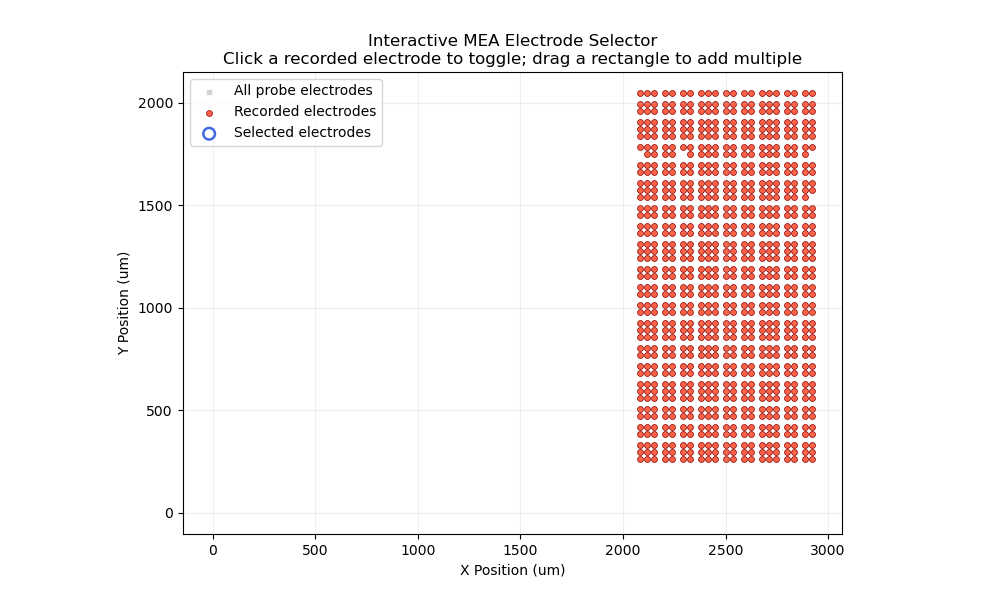

In [22]:
# Interactive multi-electrode selector for downstream LFP analysis
%matplotlib widget

channel_to_electrode_map = {ch_id: elec_id for elec_id, ch_id in electrode_to_channel_map.items() if ch_id is not None}
channel_to_electrode_map.update({str(ch_id): elec_id for ch_id, elec_id in channel_to_electrode_map.items()})


def _coerce_channel_id(channel_id):
    """Return the channel ID using the same type as the recording channel IDs when possible."""
    if channel_id in channel_to_electrode_map:
        return channel_id
    channel_id_str = str(channel_id)
    if channel_id_str in channel_to_electrode_map:
        return channel_id_str
    for existing_channel_id in recording.get_channel_ids():
        if str(existing_channel_id) == channel_id_str:
            return existing_channel_id
    return channel_id


def get_electrode_info(electrode_id=None, channel_id=None):
    """Return electrode/channel metadata for an electrode ID or channel ID."""
    if electrode_id is not None:
        electrode_id = int(electrode_id)
        ch_id = electrode_to_channel_map.get(electrode_id)
        return {
            'electrode_id': electrode_id,
            'channel_id': ch_id,
            'recording': ch_id is not None,
        }
    if channel_id is not None:
        ch_id = _coerce_channel_id(channel_id)
        elec_id = channel_to_electrode_map.get(ch_id, channel_to_electrode_map.get(str(ch_id)))
        return {
            'electrode_id': elec_id,
            'channel_id': ch_id,
            'recording': elec_id is not None,
        }
    raise ValueError("Provide either electrode_id or channel_id")


recorded_electrode_ids = np.array([eid for eid, ch in electrode_to_channel_map.items() if ch is not None], dtype=int)
recorded_channel_ids = np.array([electrode_to_channel_map[eid] for eid in recorded_electrode_ids], dtype=object)
recorded_positions = contact_positions[recorded_electrode_ids]
recorded_lookup = {int(eid): ch for eid, ch in zip(recorded_electrode_ids, recorded_channel_ids)}

selected_electrode_ids = []
selected_channel_ids = []
selected_electrode_table = pd.DataFrame(columns=['electrode_id', 'channel_id', 'x_um', 'y_um'])


def _selection_table(electrode_ids):
    rows = []
    for eid in electrode_ids:
        eid = int(eid)
        ch_id = recorded_lookup.get(eid)
        if ch_id is None:
            continue
        x_um, y_um = contact_positions[eid]
        rows.append({
            'electrode_id': eid,
            'channel_id': ch_id,
            'x_um': float(x_um),
            'y_um': float(y_um),
        })
    return pd.DataFrame(rows, columns=['electrode_id', 'channel_id', 'x_um', 'y_um'])


def set_selected_electrodes(electrode_ids, append=False):
    """Set or append selected recorded electrodes and update globals for downstream cells."""
    global selected_electrode_ids, selected_channel_ids, selected_electrode_table

    valid = []
    invalid = []
    for eid in electrode_ids:
        try:
            eid = int(eid)
        except (TypeError, ValueError):
            invalid.append(eid)
            continue
        if eid in recorded_lookup:
            valid.append(eid)
        else:
            invalid.append(eid)

    if append:
        valid = selected_electrode_ids + valid

    selected_electrode_ids = sorted(dict.fromkeys(valid))
    selected_channel_ids = [recorded_lookup[eid] for eid in selected_electrode_ids]
    selected_electrode_table = _selection_table(selected_electrode_ids)
    _refresh_selector_plot()
    _print_selection_status(invalid)
    return selected_electrode_table


def clear_selected_electrodes(_=None):
    return set_selected_electrodes([], append=False)


def _refresh_selector_plot():
    if len(selected_electrode_ids) == 0:
        selected_plot.set_offsets(np.empty((0, 2)))
    else:
        selected_plot.set_offsets(contact_positions[selected_electrode_ids])
    fig.canvas.draw_idle()


def _print_selection_status(invalid=None):
    invalid = invalid or []
    with selector_output:
        selector_output.clear_output()
        print(f"Selected {len(selected_electrode_ids)} recorded electrode(s).")
        if selected_electrode_ids:
            display(selected_electrode_table)
            print("Use these globals in downstream cells:")
            print(f"selected_electrode_ids = {selected_electrode_ids}")
            print(f"selected_channel_ids = {selected_channel_ids}")
        if invalid:
            print(f"Ignored unrecorded/invalid electrode IDs: {invalid}")


def _parse_electrode_text(text):
    tokens = text.replace('\n', ',').replace(';', ',').replace(' ', ',').split(',')
    return [token.strip() for token in tokens if token.strip()]


def apply_manual_selection(_=None):
    return set_selected_electrodes(_parse_electrode_text(manual_electrode_ids.value), append=False)


def append_manual_selection(_=None):
    return set_selected_electrodes(_parse_electrode_text(manual_electrode_ids.value), append=True)


def _toggle_electrode(eid):
    current = set(selected_electrode_ids)
    eid = int(eid)
    if eid in current:
        current.remove(eid)
    else:
        current.add(eid)
    return set_selected_electrodes(sorted(current), append=False)


def on_pick(event):
    if event.artist is not recorded_scatter or len(event.ind) == 0:
        return
    mouse_xy = np.array([event.mouseevent.xdata, event.mouseevent.ydata], dtype=float)
    candidate_positions = recorded_positions[event.ind]
    nearest_local_idx = np.argmin(np.sum((candidate_positions - mouse_xy) ** 2, axis=1))
    eid = recorded_electrode_ids[event.ind[nearest_local_idx]]
    _toggle_electrode(eid)


def on_rectangle_select(eclick, erelease):
    if eclick.xdata is None or erelease.xdata is None:
        return
    x0, x1 = sorted([eclick.xdata, erelease.xdata])
    y0, y1 = sorted([eclick.ydata, erelease.ydata])
    mask = (
        (recorded_positions[:, 0] >= x0) & (recorded_positions[:, 0] <= x1) &
        (recorded_positions[:, 1] >= y0) & (recorded_positions[:, 1] <= y1)
    )
    set_selected_electrodes(recorded_electrode_ids[mask], append=True)


fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(contact_positions[:, 0], contact_positions[:, 1], s=10, c='lightgray', marker='s', label='All probe electrodes')
recorded_scatter = ax.scatter(
    recorded_positions[:, 0],
    recorded_positions[:, 1],
    s=18,
    c='tomato',
    edgecolors='darkred',
    linewidths=0.5,
    label='Recorded electrodes',
    picker=True,
    pickradius=5,
)
selected_plot = ax.scatter(
    [],
    [],
    s=70,
    facecolors='none',
    edgecolors='royalblue',
    linewidths=1.8,
    label='Selected electrodes',
)
ax.set_title('Interactive MEA Electrode Selector\nClick a recorded electrode to toggle; drag a rectangle to add multiple')
ax.set_xlabel('X Position (um)')
ax.set_ylabel('Y Position (um)')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='best')
ax.grid(alpha=0.2)

rectangle_selector = RectangleSelector(
    ax,
    on_rectangle_select,
    useblit=True,
    button=[1],
    interactive=True,
    props=dict(facecolor='royalblue', edgecolor='royalblue', alpha=0.15, fill=True),
)
fig.canvas.mpl_connect('pick_event', on_pick)

manual_electrode_ids = widgets.Text(
    value='',
    placeholder='Example: 500, 501, 520',
    description='Electrodes:',
    layout=widgets.Layout(width='520px'),
)
set_button = widgets.Button(description='Set from text', button_style='primary')
append_button = widgets.Button(description='Append from text')
clear_button = widgets.Button(description='Clear selection', button_style='warning')
selector_output = widgets.Output()

set_button.on_click(apply_manual_selection)
append_button.on_click(append_manual_selection)
clear_button.on_click(clear_selected_electrodes)

display(widgets.HBox([manual_electrode_ids, set_button, append_button, clear_button]))
display(selector_output)
_print_selection_status()

print('Downstream variables created: selected_electrode_ids, selected_channel_ids, selected_electrode_table')
print('Programmatic use: set_selected_electrodes([500, 501]) or clear_selected_electrodes()')

In [ ]:
# LFP band-power helper functions
LFP_BANDS = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}


def _require_selected_electrodes(electrode_ids=None):
    if electrode_ids is None:
        electrode_ids = selected_electrode_ids
    electrode_ids = [int(eid) for eid in electrode_ids]
    if len(electrode_ids) == 0:
        raise ValueError('Select at least one recorded electrode before running LFP analysis.')
    channels = []
    valid_electrodes = []
    for eid in electrode_ids:
        ch_id = recorded_lookup.get(eid)
        if ch_id is None:
            print(f'Ignoring electrode {eid}: not recorded.')
            continue
        valid_electrodes.append(eid)
        channels.append(ch_id)
    if len(channels) == 0:
        raise ValueError('None of the requested electrodes are recorded.')
    return valid_electrodes, channels


def _get_traces_safe(recording_obj, start_frame, end_frame, channel_ids, return_scaled=True):
    try:
        return recording_obj.get_traces(
            start_frame=start_frame,
            end_frame=end_frame,
            channel_ids=channel_ids,
            return_scaled=return_scaled,
        )
    except TypeError:
        return recording_obj.get_traces(
            start_frame=start_frame,
            end_frame=end_frame,
            channel_ids=channel_ids,
        )


def get_selected_lfp_traces(
    electrode_ids=None,
    start_sec=0,
    duration_sec=None,
    recording_obj=None,
    return_scaled=True,
):
    """Load LFP traces for selected electrodes and return traces, times, electrode IDs, and channel IDs.

    Set duration_sec=None to load from start_sec through the end of the recording.
    """
    if recording_obj is None:
        recording_obj = recording_lfp
    fs = recording_obj.get_sampling_frequency()
    valid_electrodes, channels = _require_selected_electrodes(electrode_ids)
    start_frame = max(0, int(round(start_sec * fs)))
    if duration_sec is None:
        end_frame = recording_obj.get_num_samples()
    else:
        end_frame = min(recording_obj.get_num_samples(), start_frame + int(round(duration_sec * fs)))
    if end_frame <= start_frame:
        raise ValueError('Requested LFP trace window is empty.')
    traces = _get_traces_safe(recording_obj, start_frame, end_frame, channels, return_scaled=return_scaled)
    times = np.arange(start_frame, end_frame) / fs
    return traces, times, valid_electrodes, channels


def compute_lfp_band_power_over_time(
    electrode_ids=None,
    recording_obj=None,
    start_sec=0,
    end_sec=None,
    window_sec=10,
    step_sec=5,
    bands=None,
    welch_segment_sec=2,
    return_scaled=True,
):
    """Compute Welch band power in sliding windows for selected electrodes."""
    if recording_obj is None:
        recording_obj = recording_lfp
    if bands is None:
        bands = LFP_BANDS

    fs = recording_obj.get_sampling_frequency()
    valid_electrodes, channels = _require_selected_electrodes(electrode_ids)
    total_sec = recording_obj.get_num_samples() / fs
    if end_sec is None:
        end_sec = total_sec
    start_sec = max(0, float(start_sec))
    end_sec = min(float(end_sec), total_sec)
    if end_sec <= start_sec:
        raise ValueError('Requested LFP analysis interval is empty.')

    window_frames = int(round(window_sec * fs))
    step_frames = int(round(step_sec * fs))
    if window_frames <= 0 or step_frames <= 0:
        raise ValueError('window_sec and step_sec must be positive.')

    start_frame = int(round(start_sec * fs))
    end_frame = int(round(end_sec * fs))
    nperseg = max(1, min(int(round(welch_segment_sec * fs)), window_frames))
    rows = []

    for win_start in range(start_frame, max(start_frame, end_frame - window_frames) + 1, step_frames):
        win_end = win_start + window_frames
        if win_end > end_frame:
            break
        traces = _get_traces_safe(recording_obj, win_start, win_end, channels, return_scaled=return_scaled)
        freqs, psd = signal.welch(traces, fs=fs, nperseg=nperseg, axis=0)
        center_time_sec = (win_start + win_end) / (2 * fs)

        for electrode_id, channel_id, channel_idx in zip(valid_electrodes, channels, range(len(channels))):
            for band_name, (f_min, f_max) in bands.items():
                band_mask = (freqs >= f_min) & (freqs < f_max)
                if not np.any(band_mask):
                    power = np.nan
                else:
                    power = float(np.trapz(psd[band_mask, channel_idx], freqs[band_mask]))
                rows.append({
                    'electrode_id': electrode_id,
                    'channel_id': channel_id,
                    'time_sec': center_time_sec,
                    'window_start_sec': win_start / fs,
                    'window_end_sec': win_end / fs,
                    'band': band_name,
                    'freq_min_hz': f_min,
                    'freq_max_hz': f_max,
                    'power': power,
                    'power_db': 10 * np.log10(power + np.finfo(float).eps),
                })

    return pd.DataFrame(rows)


lfp_band_power_df = pd.DataFrame()
lfp_initial_end_sec = total_duration_sec

if len(selected_electrode_ids) == 0:
    print('Select electrodes in the previous cell, then rerun this cell to compute LFP band power.')
else:
    lfp_band_power_df = compute_lfp_band_power_over_time(
        start_sec=0,
        end_sec=lfp_initial_end_sec,
        window_sec=10,
        step_sec=5,
    )
    display(lfp_band_power_df.head())
    print(f'Computed {len(lfp_band_power_df)} band-power rows for 0-{lfp_initial_end_sec:.1f} s.')


/tmp/ipykernel_2984922/622213330.py:34: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  return recording_obj.get_traces(
/tmp/ipykernel_2984922/622213330.py:126: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power = float(np.trapz(psd[band_mask, channel_idx], freqs[band_mask]))


,electrode_id,channel_id,time_sec,window_start_sec,window_end_sec,band,freq_min_hz,freq_max_hz,power,power_db
0,176,205,5.0,0.0,10.0,delta,0.5,4,200.620989,23.023764
1,176,205,5.0,0.0,10.0,theta,4.0,8,64.111550,18.069363
2,176,205,5.0,0.0,10.0,alpha,8.0,12,20.462413,13.109568
3,176,205,5.0,0.0,10.0,beta,12.0,30,32.530627,15.122924
4,176,205,5.0,0.0,10.0,low_gamma,30.0,80,17.261780,12.370856


Computed 8604 band-power rows for 0-1200.0 s.


: 

In [ ]:
# Plot selected-electrode LFP trace, Welch spectrum, and band power over time


def plot_selected_lfp_summary(
    electrode_ids=None,
    trace_start_sec=0,
    trace_duration_sec=None,
    band_power_df=None,
    band_power_start_sec=0,
    band_power_end_sec=None,
    window_sec=10,
    step_sec=5,
    max_spectrum_hz=150,
    facet_by_electrode=False,
    save_html_path=None,
    include_plotlyjs='cdn',
    max_trace_plot_points=20000,
):
    from plotly.subplots import make_subplots

    band_order = ['delta', 'theta', 'alpha', 'beta', 'low_gamma', 'high_gamma']
    band_colors = {
        'delta': '#4c78a8',
        'theta': '#f58518',
        'alpha': '#54a24b',
        'beta': '#e45756',
        'low_gamma': '#b279a2',
        'high_gamma': '#9d755d',
    }
    trace_colors = px.colors.qualitative.Plotly

    valid_electrodes, channels = _require_selected_electrodes(electrode_ids)
    fs = recording_lfp.get_sampling_frequency()
    total_recording_sec = recording_lfp.get_num_samples() / fs
    trace_end_sec = total_recording_sec if trace_duration_sec is None else trace_start_sec + trace_duration_sec
    desired_band_power_end_sec = total_recording_sec if band_power_end_sec is None else min(band_power_end_sec, total_recording_sec)

    traces, times, valid_electrodes, channels = get_selected_lfp_traces(
        valid_electrodes,
        start_sec=trace_start_sec,
        duration_sec=trace_duration_sec,
    )

    needs_band_power = band_power_df is None or band_power_df.empty
    if not needs_band_power:
        existing_electrodes = set(band_power_df['electrode_id'].astype(int).unique())
        needs_band_power = not set(valid_electrodes).issubset(existing_electrodes)
    if not needs_band_power and 'window_end_sec' in band_power_df.columns:
        covered_end_sec = band_power_df.loc[
            band_power_df['electrode_id'].astype(int).isin(valid_electrodes),
            'window_end_sec',
        ].max()
        needs_band_power = not np.isfinite(covered_end_sec) or covered_end_sec < desired_band_power_end_sec

    if needs_band_power:
        band_power_df = compute_lfp_band_power_over_time(
            valid_electrodes,
            start_sec=band_power_start_sec,
            end_sec=desired_band_power_end_sec,
            window_sec=window_sec,
            step_sec=step_sec,
        )

    freqs, psd = signal.welch(traces, fs=fs, nperseg=min(int(round(2 * fs)), traces.shape[0]), axis=0)
    mean_psd_db = 10 * np.log10(np.nanmean(psd, axis=1) + np.finfo(float).eps)
    spectrum_mask = (freqs > 0) & (freqs <= max_spectrum_hz)
    band_power_df = band_power_df.copy()
    band_power_df['band'] = pd.Categorical(band_power_df['band'], categories=band_order, ordered=True)

    fig = make_subplots(
        rows=2,
        cols=2,
        specs=[[{'colspan': 2}, None], [{}, {}]],
        vertical_spacing=0.12,
        horizontal_spacing=0.09,
        row_heights=[0.54, 0.46],
        subplot_titles=(
            'Selected-electrode LFP trace - full recording',
            'Mean Welch spectrum across selected electrodes',
            'Mean LFP band power over time across selected electrodes',
        ),
    )

    trace_scale = np.nanpercentile(np.abs(traces), 95)
    if not np.isfinite(trace_scale) or trace_scale == 0:
        trace_scale = 1.0
    offsets = np.arange(traces.shape[1]) * trace_scale * 2.5

    plot_step = max(1, int(np.ceil(len(times) / max_trace_plot_points)))
    plot_times = times[::plot_step]
    plot_traces = traces[::plot_step]

    for idx, (electrode_id, channel_id) in enumerate(zip(valid_electrodes, channels)):
        fig.add_trace(
            go.Scattergl(
                x=plot_times,
                y=plot_traces[:, idx] + offsets[idx],
                mode='lines',
                line=dict(color=trace_colors[idx % len(trace_colors)], width=1.2),
                name=f'E{electrode_id} / Ch {channel_id}',
                legendgroup=f'electrode-{electrode_id}',
                hovertemplate=(
                    f'Electrode {electrode_id}<br>'
                    f'Channel {channel_id}<br>'
                    'Time: %{x:.3f} s<br>'
                    'Amplitude + offset: %{y:.3g}<extra></extra>'
                ),
            ),
            row=1,
            col=1,
        )

    fig.add_trace(
        go.Scatter(
            x=freqs[spectrum_mask],
            y=mean_psd_db[spectrum_mask],
            mode='lines',
            line=dict(color='#1f1f1f', width=2.2),
            name='Mean PSD',
            showlegend=False,
            hovertemplate='Frequency: %{x:.2f} Hz<br>PSD: %{y:.2f} dB<extra></extra>',
        ),
        row=2,
        col=1,
    )

    for band_name in band_order:
        if band_name not in LFP_BANDS:
            continue
        f_min, f_max = LFP_BANDS[band_name]
        if f_min >= max_spectrum_hz:
            continue
        fig.add_vrect(
            x0=f_min,
            x1=min(f_max, max_spectrum_hz),
            fillcolor=band_colors[band_name],
            opacity=0.08,
            line_width=0,
            layer='below',
            row=2,
            col=1,
        )

    grouped = (
        band_power_df.groupby(['time_sec', 'band'], as_index=False, observed=True)['power_db']
        .mean()
        .sort_values(['band', 'time_sec'])
    )
    for band_name in band_order:
        band_df = grouped[grouped['band'] == band_name]
        if band_df.empty:
            continue
        fig.add_trace(
            go.Scatter(
                x=band_df['time_sec'],
                y=band_df['power_db'],
                mode='lines+markers',
                marker=dict(size=6, color=band_colors[band_name]),
                line=dict(color=band_colors[band_name], width=2.0),
                name=band_name.replace('_', ' '),
                legendgroup=f'band-{band_name}',
                hovertemplate='Time: %{x:.2f} s<br>Power: %{y:.2f} dB<extra></extra>',
            ),
            row=2,
            col=2,
        )

    y_min = grouped['power_db'].min() if not grouped.empty else np.nan
    y_max = grouped['power_db'].max() if not grouped.empty else np.nan
    band_y_range = None
    if np.isfinite(y_min) and np.isfinite(y_max):
        pad = max(0.5, 0.12 * (y_max - y_min if y_max > y_min else 1.0))
        band_y_range = [y_min - pad, y_max + pad]

    fig.update_xaxes(title_text='Time (s)', range=[trace_start_sec, trace_end_sec], row=1, col=1)
    fig.update_yaxes(title_text='Amplitude + offset', row=1, col=1)
    fig.update_xaxes(title_text='Frequency (Hz)', range=[0, max_spectrum_hz], row=2, col=1)
    fig.update_yaxes(title_text='PSD (dB)', row=2, col=1)
    fig.update_xaxes(title_text='Time (s)', row=2, col=2)
    fig.update_yaxes(title_text='Band power (dB)', range=band_y_range, row=2, col=2)

    fig.update_layout(
        autosize=True,
        height=760,
        width=None,
        template='plotly_white',
        hovermode='closest',
        margin=dict(l=60, r=35, t=70, b=55),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=-0.22,
            xanchor='left',
            x=0,
            itemclick='toggle',
            itemdoubleclick='toggleothers',
        ),
    )

    show_config = {'responsive': True, 'displaylogo': False}
    if save_html_path is not None:
        fig.write_html(save_html_path, include_plotlyjs=include_plotlyjs, config=show_config)
    fig.show(config=show_config)
    return fig, band_power_df


if len(selected_electrode_ids) == 0:
    print('Select electrodes in the selector cell, then rerun this cell to plot LFP summaries.')
else:
    fig_lfp_summary, lfp_band_power_df = plot_selected_lfp_summary(
        band_power_df=lfp_band_power_df,
        band_power_end_sec=None,
    )




## TODO

Lazy load. seperate the computing and displaying.

1. Raw trace file no filter
2. LFP/Spike Filtered
3. Similar traces to: sw.plot_traces
